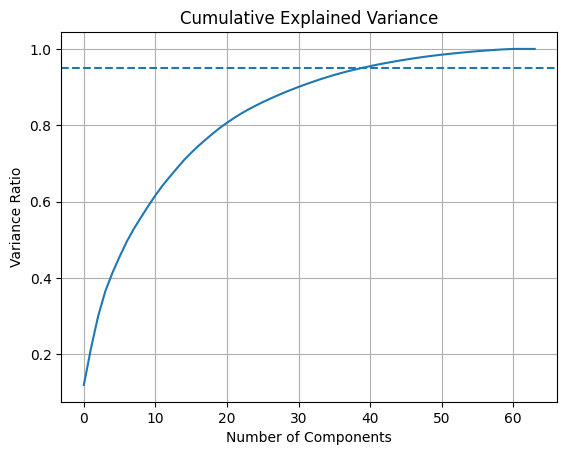

Components needed for 95% variance: 40


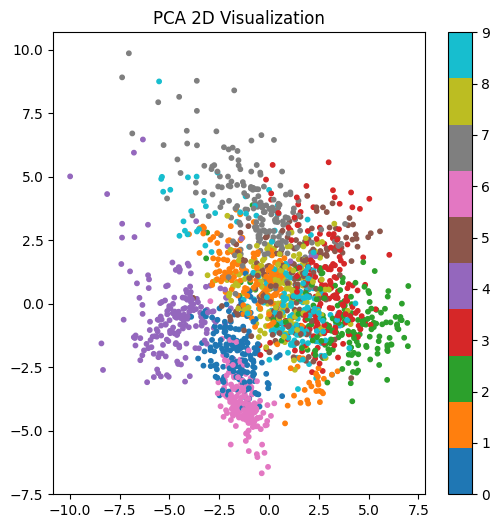

Silhouette Score (Original Data): 0.13937726851699628
Silhouette Score (PCA 2D): 0.37780340240085214
PCA model saved as pca_model.pkl


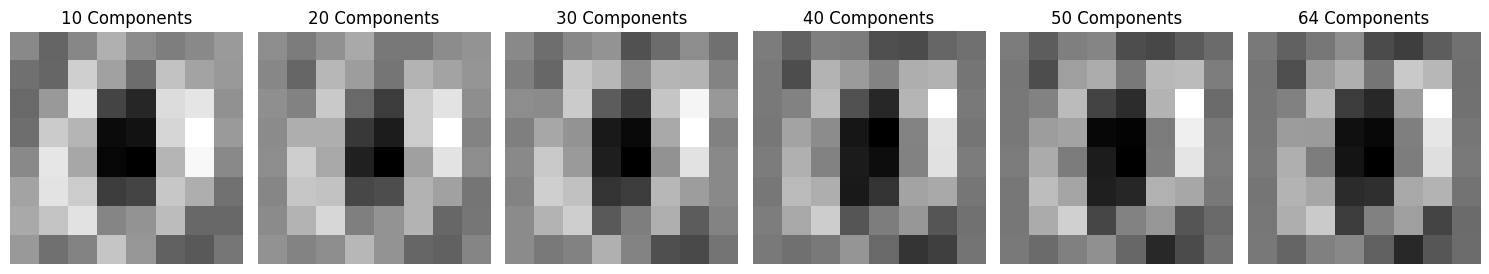

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

digits = load_digits()
X = digits.data
y = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit(X_scaled)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure()
plt.plot(explained_variance)
plt.axhline(y=0.95, linestyle="--")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance Ratio")
plt.grid()
plt.show()

n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print("Components needed for 95% variance:", n_components_95)

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="tab10", s=10)
plt.title("PCA 2D Visualization")
plt.colorbar()
plt.show()

kmeans_raw = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(X_scaled)

kmeans_pca = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_2d)

score_raw = silhouette_score(X_scaled, labels_raw)
score_pca = silhouette_score(X_2d, labels_pca)

print("Silhouette Score (Original Data):", score_raw)
print("Silhouette Score (PCA 2D):", score_pca)

pca_model = PCA(n_components=n_components_95)
X_pca_opt = pca_model.fit_transform(X_scaled)

joblib.dump(pca_model, "pca_model.pkl")
print("PCA model saved as pca_model.pkl")

max_features = X_scaled.shape[1]

recon_components = [10, 20, 30, 40, 50, 64]
recon_components = [n for n in recon_components if n <= max_features]

fig, axes = plt.subplots(1, len(recon_components), figsize=(15,4))

for i, n in enumerate(recon_components):

    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_pca)

    image = X_reconstructed[0].reshape(8, 8)

    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"{n} Components")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [31]:
pca_model = PCA(n_components=n_components_95)
pca_model.fit(X_scaled)

joblib.dump(pca_model, "pca_model.pkl")

print("PCA model saved as pca_model.pkl")

PCA model saved as pca_model.pkl


In [33]:
from google.colab import files
files.download("pca_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>